# 29 - L2 Regularization (Weight Decay)

**Section:** Regularization | **Prereqs:** `Regularization/Dropuout.ipynb` | **Next:** `Regularization/Weight_Regularization_(L1).ipynb`

Add the squared size of the weights to the loss:

    total_loss = data_loss + lambda * sum(w^2)

Gradient descent now has two jobs - fit the data *and* keep the weights small -
and the trade-off is set by `lambda`. Smaller weights mean a smoother, less
wiggly function, which is the formal sense in which the model becomes 'simpler'.

**In PyTorch it is one argument:** `weight_decay=lambda` on the optimizer.
No change to the loss, the model or the loop.

**Why it is called decay.** The gradient of `lambda*w^2` is `2*lambda*w`, so each
step subtracts a fraction of the weight itself: unused weights shrink towards
zero exponentially. Note this also decays the *biases*, which is not what the
textbook penalty says - production code usually excludes biases and norm layers
via parameter groups.

**Typical values:** 1e-5 to 1e-2. The sweep here goes to 0.1, which is far past
useful - and the accuracy collapse at the top end is the point.

**Read the sweep, not a single point.** Each lambda is one training run, so the
point-to-point wobble is run-to-run noise. What matters is the shape: a broad
plateau at small lambda and a collapse once the penalty dominates.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader , TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris


In [11]:
iris = load_iris()

data = torch.tensor(iris.data, dtype=torch.float)
label = torch.tensor(iris.target, dtype=torch.long)

In [12]:
# Iris, 75/25 split, batches of 8.
data_train, data_test, label_train, label_test = train_test_split(data,label, test_size=0.25)

train_data = TensorDataset(data_train, label_train)
test_data = TensorDataset(data_test, label_test)


bs = 8
train_loader = DataLoader(train_data ,batch_size=bs ,shuffle=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [13]:
# 4 -> 128 -> 128 -> 3, but note self.hidden_layer is applied three times.
# That is weight tying: one set of weights reused at three depths, not three
# independent layers. Probably unintended, but it does make the model small
# enough that L2 has a visible effect.
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(4,128)
    self.hidden_layer = nn.Linear(128,128)
    self.output_layer = nn.Linear(128,3)

  def forward(self,x):

    x = F.relu(self.input_layer(x))

    x = F.relu(self.hidden_layer(x))
    x = F.relu(self.hidden_layer(x))
    x = F.relu(self.hidden_layer(x))

    return self.output_layer(x)


In [14]:
# The whole implementation of L2 in PyTorch: weight_decay=lambda.
# Everything else - loss, loop, model - is unchanged.
# Note this decays biases too; excluding them needs optimizer parameter groups.
def create_model(L2lambda):

  Classifier = model()

  lossFunc = nn.CrossEntropyLoss()

  lr = 0.01
  optimizer = torch.optim.SGD(Classifier.parameters(), lr=lr, weight_decay=L2lambda)

  return Classifier , lossFunc , optimizer

In [15]:
# Training function. Accuracy is recorded per BATCH inside the batch loop, then
# averaged per epoch - and the test pass runs once per epoch, not once per run.
# Both lists therefore hold one value per epoch, so the sweep can compare final
# accuracies and also plot a learning curve if you want one.
def train_model(L2):
  Classifier , lossFunc , optimizer = create_model(L2) # L2 decay rate is 0.001
  epochs = 1000
  losses = torch.zeros(epochs)

  train_accuracy = []
  test_accuracy = []


  for i in range(epochs):

    Classifier.train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:

      yhat = Classifier.forward(x)

      loss = lossFunc(yhat, y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # Batch accuracy
      batch_acc.append( 100*(torch.mean((torch.argmax(yhat,axis=1) == y).float())).item() )

    losses[i] = np.mean(batch_loss)
    train_accuracy.append(np.mean(batch_acc))

    Classifier.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      preds = Classifier.forward(X)
      test_accuracy.append(100*(torch.mean((torch.argmax(preds,axis=1) == Y).float())).item())


  return train_accuracy,test_accuracy

In [16]:
# Ten L2 strengths, 0 to 0.1, linearly spaced. 0.1 is very strong for a network
# this size; the sweep is deliberately wide enough to show the damage.
L2_rate = np.linspace(0,0.1,10)
L2_rate

array([0.        , 0.01111111, 0.02222222, 0.03333333, 0.04444444,
       0.05555556, 0.06666667, 0.07777778, 0.08888889, 0.1       ])

In [17]:
# Ten training runs, one per lambda. Each returns per-epoch accuracy lists, so
# [-1] below is the final epoch's value.
testArr = []
trainArr = []

for i in L2_rate:
  trainAcc, testAcc = train_model(i)
  testArr.append(testAcc[-1].detach())
  trainArr.append(trainAcc[-1].detach())

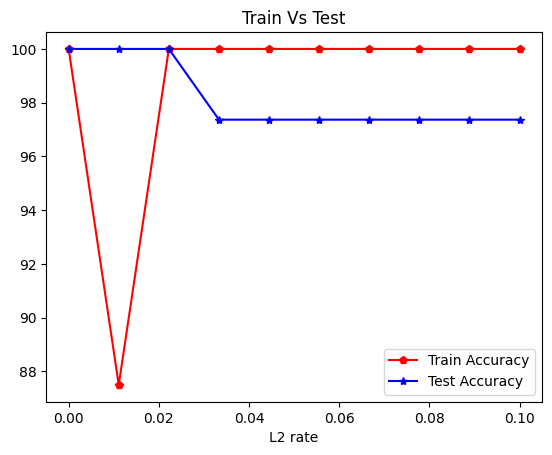

In [18]:
# Final accuracy vs L2 strength. Expect a mild peak at a small non-zero lambda
# and a clear collapse as it grows - past a point the penalty dominates the data
# term and the model is optimising for small weights instead of correct answers.
plt.plot(L2_rate,trainArr ,"rp-", label="Train Accuracy")
plt.plot(L2_rate,testArr, "b*-", label="Test Accuracy")
plt.title("Train Vs Test")
plt.xlabel("L2 rate")
plt.legend();